c:\tools\Anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:21:58] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classifier Performance for Private Service Line Material:
Accuracy: 0.8507644021464007
AUC: 0.9244529804102967
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.81      0.77      3015
           1       0.91      0.87      0.89      6862

    accuracy                           0.85      9877
   macro avg       0.82      0.84      0.83      9877
weighted avg       0.86      0.85      0.85      9877



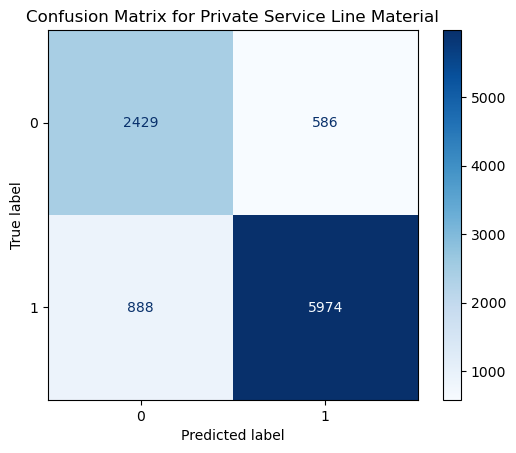

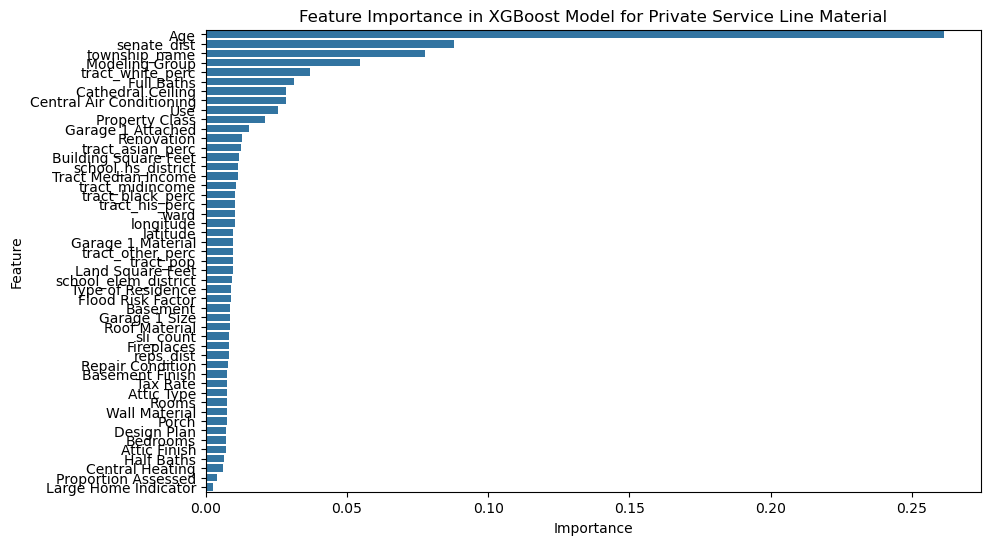

c:\tools\Anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:21:59] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classifier Performance for Public Service Line Material:
Accuracy: 0.8734433532449124
AUC: 0.9428375477638472
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.85      0.82      3432
           1       0.92      0.88      0.90      6445

    accuracy                           0.87      9877
   macro avg       0.86      0.87      0.86      9877
weighted avg       0.88      0.87      0.87      9877



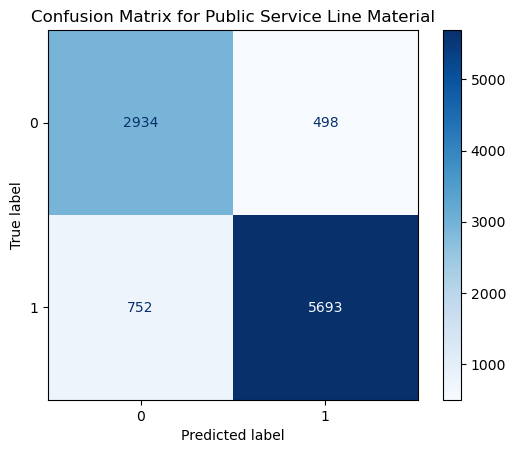

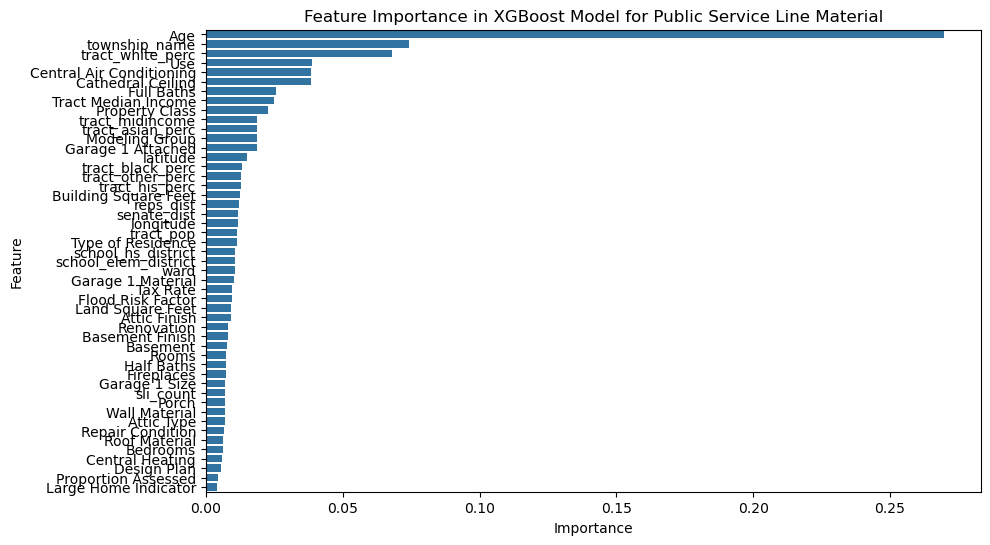

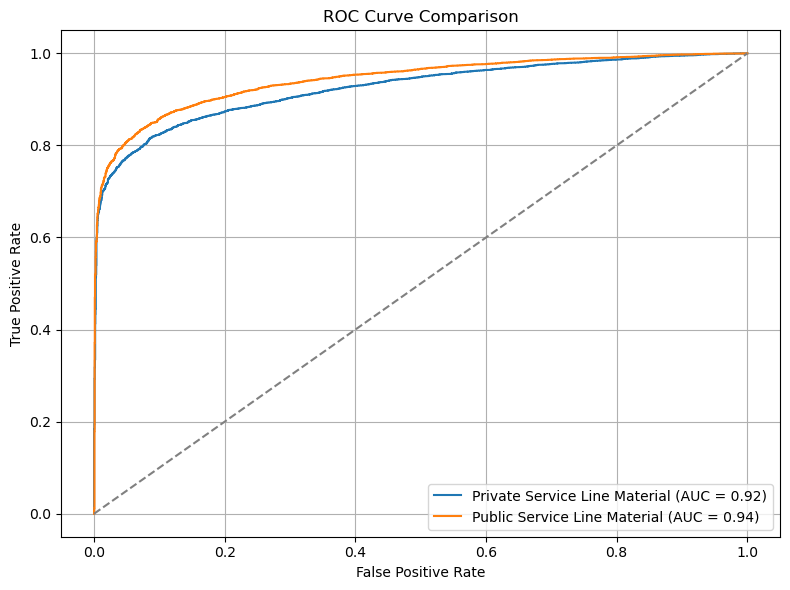

In [1]:
# import libraries
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv('assessor_rm_sli_merged.csv', low_memory=False)

# drop redundant and unnecessary columns
drop_columns = [
    "Assessment Triad", "FEMA Floodplain", "geoposition", "Sale Price",
    "Garage 1 Area", "property_city", "municipality", "ssa_name", "ssa_no",
    "ohare_noise", "floodplain", "fs_flood_risk_direction", "withinmr100", "withinmr101300",
    "indicator_has_latlon", "Cleaned Address", "Address", "property_address",
    "property_zip", "tract_geoid", "tax_rate", "tract-Midincome", "township", "nbhd", "Apartments"
]
df.drop(columns=drop_columns, inplace=True, errors='ignore')

# filter dataset for confirmed 'LEAD' and 'NOT LEAD' only
df = df[df['Private Service Line Material'].isin(['LEAD', 'NOT LEAD'])]
df = df[df['Public Service Line Material'].isin(['LEAD', 'NOT LEAD'])]

# handling categorical features with missing values
categorical_fillna = [
    "Property Class", "Modeling Group", "Large Home Indicator", "Wall Material",
    "Roof Material", "Basement", "Basement Finish", "Central Heating", "Central Air Conditioning",
    "Attic Type", "Design Plan", "Cathedral Ceiling", "Garage 1 Size",
    "Garage 1 Material", "Garage 1 Attached", "Repair Condition", "Use", "Type of Residence",
    "Attic Finish", "Renovation", "Porch", "township_name", "reps_dist", "senate_dist",
    "ward", "school_elem_district", "school_hs_district"
]
df[categorical_fillna] = df[categorical_fillna].astype(str).fillna("Unknown")

# convert categorical features into numerical representations
label_encoders = {}
for col in categorical_fillna:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # store encoders for potential inverse transformations

# handling numerical missing values by filling with median
numerical_features = ["Flood Risk Factor", "Land Square Feet", "Age", "Rooms", "Bedrooms", "Full Baths",
                      "Half Baths", "Building Square Feet", "Tract Median Income", "tract_pop",
                      "tract_white_perc", "tract_black_perc", "tract_asian_perc", "tract_his_perc",
                      "tract_other_perc", "longitude", "latitude", "sli_count"]
df[numerical_features] = df[numerical_features].astype(float).fillna(df[numerical_features].median())

# ensure all features in X are numeric
X = df.drop(columns=["Private Service Line Material", "Public Service Line Material", "Property Address"], errors='ignore')
y_private = df["Private Service Line Material"]
y_public = df["Public Service Line Material"]

# convert target variables to numeric
y_private = LabelEncoder().fit_transform(y_private.astype(str))
y_public = LabelEncoder().fit_transform(y_public.astype(str))

# function to train and evaluate XGBoost model
def train_xgboost(X, y, target_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    xgb_model = xgb.XGBClassifier(eval_metric="logloss", use_label_encoder=False, random_state=42)
    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_proba = xgb_model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    print(f"XGBoost Classifier Performance for {target_name}:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("AUC:", auc)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix for {target_name}')
    plt.show()

    # feature importance
    feature_importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances['Importance'], y=feature_importances['Feature'])
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(f'Feature Importance in XGBoost Model for {target_name}')
    plt.show()

    return fpr, tpr, auc, target_name

# train models for both target variables
fpr_priv, tpr_priv, auc_priv, name_priv = train_xgboost(X, y_private, 'Private Service Line Material')
fpr_pub, tpr_pub, auc_pub, name_pub = train_xgboost(X, y_public, 'Public Service Line Material')

# plot both ROC curves together
plt.figure(figsize=(8, 6))
plt.plot(fpr_priv, tpr_priv, label=f'{name_priv} (AUC = {auc_priv:.2f})')
plt.plot(fpr_pub, tpr_pub, label=f'{name_pub} (AUC = {auc_pub:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# save cleaned dataset
df.to_csv("assessor_sli_cleaned.csv", index=False)
